<sub>Mario Stanke, Felix Becker, University of Greifswald, Germany</sub>
# A Simple Regression Neural Network

This notebook gives the first example of a neural network in action. To keep it simple we estimate data simulated from a univariate function.

## Generate an Artificial Dataset

In [1]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
def f(x):
    '''A simple one-dimensional function with a few extrema'''
    return np.sin(15 * x) + 9 * x - 9 * x**2

#### Simulate $(x, y)$ pairs as artificial data set

In [ ]:
np.random.seed(1)
m = 100 # number of data points (examples)
x = np.linspace(0, 1, m) # equidistant in [0,1] (both boundaries included)
y_theoretical = f(x)     # the points on the curve 
sigma = 0.2
y = y_theoretical + sigma * np.random.randn(m) # observations have noise (normal with mean 0 and variance 0.01)

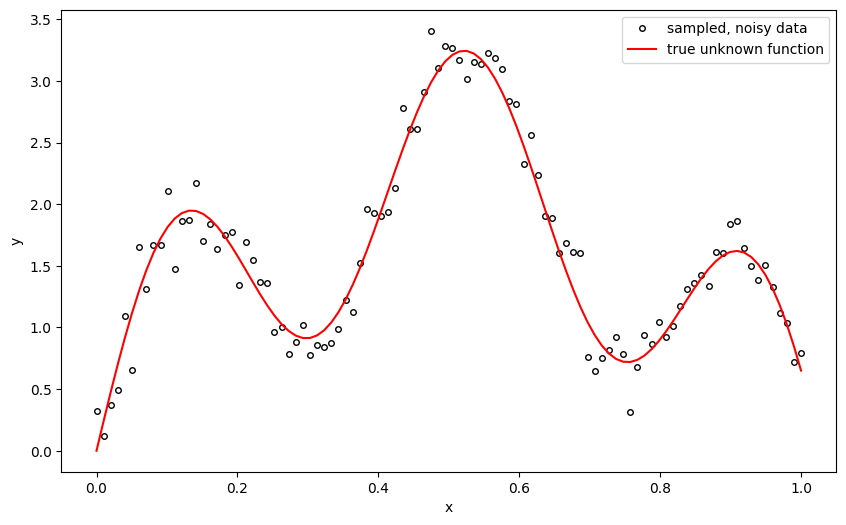

In [ ]:
def plot_curve():
    fig, ax = plt.subplots(figsize = (10, 6))
    ax.plot(x, y, 'ko', fillstyle = 'none', markersize = 4, label = "sampled, noisy data") # ko: blac(k) circle
    ax.plot(x, y_theoretical, 'r', label = "true unknown function")
    plt.xlabel("x")
    plt.ylabel("y")
    return ax

ax = plot_curve()
ax.legend();

## Create Neural Network Model  
We will use [```tf.keras```](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras), a high-level approach to neural network design and learning. The NN shall have 2 hidden layers with 8 neurons each. As activation functions we chose the logistic sigmoid function.

<img src="nn8-8.png" alt="network architecture" width="500"/>

In [ ]:
tf.random.set_seed(1) # so we all get the same pseudorandom results

# a neural network is a stack of layers, in keras called "Sequential" model
model = tf.keras.models.Sequential() # so far the stack is empty, 0 layers
model.add(Input(shape=(1,))) # implicitly specifies the input dimension

# add neural network layers one by one
# Dense is a fully connected layer, parametrized by a matrix of shape (input_units, output_units).
# The first number given in Dense is the number of output units, the number of input units is implicit.
# By default use_bias=True which adds output_units parameters for each layer
model.add(Dense(8, activation = tf.nn.sigmoid)) # input dimension only required for first layer
model.add(Dense(8, activation = tf.nn.sigmoid))
model.add(Dense(1))

model.summary()     # summarizes layers and parameters
model.get_weights() # a look under the 'hood' for teaching purposes

2025-03-08 20:39:24.112282: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-08 20:39:24.112732: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

[array([[ 0.37675905,  0.24505305, -0.47336552,  0.6496829 , -0.7480515 ,
         -0.46402475,  0.56225514, -0.21596831]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.53651285,  0.24570024, -0.3627029 , -0.1535044 ,  0.08780599,
         -0.5042316 ,  0.3957283 ,  0.36593902],
        [ 0.04592955, -0.34001815,  0.075432  , -0.5153913 , -0.03345352,
         -0.10068941, -0.06969136,  0.4152903 ],
        [ 0.5551745 , -0.29886252,  0.5647852 , -0.2882246 , -0.27172855,
         -0.4379594 ,  0.16235644,  0.12597883],
        [-0.09547532, -0.3904536 ,  0.11809683, -0.43862766, -0.48422813,
         -0.3437165 , -0.5976407 ,  0.05983955],
        [ 0.36628067, -0.24662033,  0.21389359, -0.48770544, -0.13956541,
         -0.57751095,  0.5862426 ,  0.2189219 ],
        [ 0.30373865,  0.01581526, -0.42348033,  0.22399837, -0.14237782,
          0.55530185,  0.32828945, -0.2989735 ],
        [-0.12502983, -0.23237062,  0.44511467, -0.44167018, -0.2

The weights are randomly initializated. This is important (why?) as can be the parameters of the distribution. We postpone parameter initialization to the next notebook.

### Compile the model

In [ ]:
# define the loss, optimization algorithm and prepare the model for gradient computation 
opti = tf.keras.optimizers.Adam(learning_rate = 0.1) # Adam is a popular method for stochastic gradient descent
model.compile(optimizer = opti, loss = 'mse') # mean squared error

### Train the parameters (learning)

In [ ]:
# execute the actual training 
history = model.fit(x, y, epochs = 2000, verbose = 0) # takes ~1m
# verbose = 1,2 gives more output

### Examine the learning progress

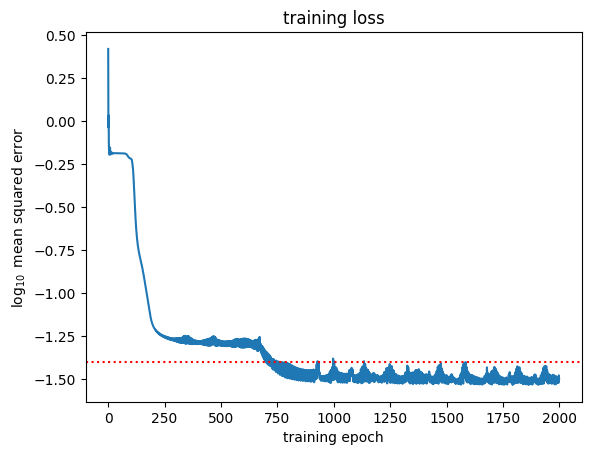

In [ ]:
plt.plot(np.log10(history.history["loss"])); # one mse value per epoch
plt.title("training loss")
plt.xlabel("training epoch")
plt.ylabel(r"$\log_{10}$ mean squared error");
plt.axhline(y = np.log10(sigma**2), color = "red", linestyle = ":");

Observe that with our choice for the measurement noise the theoretical optimum for the mean squared error *on new data* is $10^{-2}$ (red dotted line).
### Use the model for predictions

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


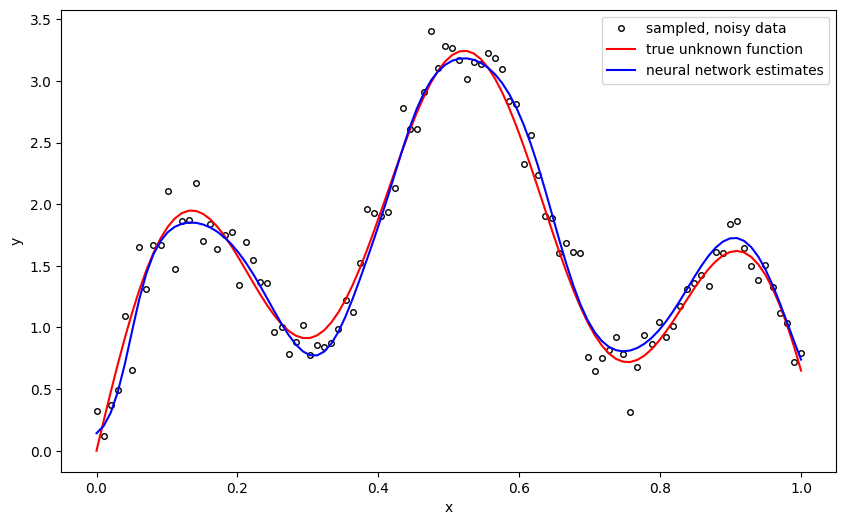

In [ ]:
x_input = x.reshape((-1, 1)) # make x a matrix (with 1 column) as expected by predict
y_pred = model.predict(x_input)

ax = plot_curve()
ax.plot(x, y_pred, 'b', label = "neural network estimates") # (b)lue
ax.legend();

To summarize, we did:
- start with data points $x$ and corresponding observations $y$
- created a simple neural network using tensorflow/keras by stacking layers
- selected optimizer, learning rate and error function from a pool of standard choices
- fitted the model to the data and visualized the result